In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("IMDb ETL Project Started!")

IMDb ETL Project Started!


In [6]:
df=pd.read_csv("../data/raw/imdb_movies.csv")

In [7]:
df.head()

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,NaN,2017.0
1,2.0,Movie 2,Sci-Fi,7.8,150.0,150.0,Nolan,Actor B,2019.0
2,3.0,Movie 3,Thriller,4.9,30.0,600.0,Spielberg,Actor D,2016.0
3,4.0,Movie 4,Thriller,9.1,100.0,600.0,Rajamouli,Actor D,2015.0
4,5.0,Movie 5,Sci-Fi,4.5,10.0,600.0,Cameron,Actor C,2022.0


In [8]:
df.shape

(5500, 9)

In [9]:
df.columns

Index(['movie_id', 'title', 'genre', 'rating', 'budget_million',
       'gross_million', 'director', 'lead_actor', 'release_year'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        5177 non-null   float64
 1   title           5500 non-null   str    
 2   genre           5500 non-null   str    
 3   rating          5211 non-null   float64
 4   budget_million  4569 non-null   float64
 5   gross_million   4583 non-null   float64
 6   director        4720 non-null   str    
 7   lead_actor      4586 non-null   str    
 8   release_year    4886 non-null   float64
dtypes: float64(5), str(4)
memory usage: 386.8 KB


In [11]:
df.isnull().sum()

movie_id          323
title               0
genre               0
rating            289
budget_million    931
gross_million     917
director          780
lead_actor        914
release_year      614
dtype: int64

A movie is duplicate when title + release_year is repeated.

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated(subset=["title","release_year"]).sum()

np.int64(27)

27 duplicates


In [32]:
# duplicates=df[df.duplicated(subset=["title","release_year"],keep=False)]

In [14]:
df=df.sort_values(by=['title','release_year','rating','gross_million'],ascending=[True,True,False,False])

In [15]:
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,NaN,2017.0
9,10.0,Movie 10,Sci-Fi,5.0,NaN,20.0,Spielberg,Actor B,2019.0
1000,1001.0,Movie 1001,Comedy,6.4,NaN,20.0,Rajamouli,Actor D,2021.0
1001,1002.0,Movie 1002,Comedy,7.6,60.0,150.0,Cameron,NaN,NaN
1002,NaN,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0
...,...,...,...,...,...,...,...,...,...
995,996.0,Movie 996,Drama,4.5,150.0,80.0,Cameron,Actor B,2020.0
996,997.0,Movie 997,Horror,6.3,150.0,300.0,NaN,Actor B,2019.0
997,998.0,Movie 998,Romance,6.9,10.0,NaN,Nolan,Actor B,2022.0
999,1000.0,Movie 999,Horror,8.0,10.0,600.0,Tarantino,Actor A,2019.0


In [16]:
a=df[df.duplicated(subset=['title','release_year'],keep=False)]

In [17]:
a

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
1124,1125.0,Movie 1124,Fantasy,8.5,NaN,150.0,Tarantino,NaN,2022.0
1123,1124.0,Movie 1124,Romance,4.8,30.0,600.0,Scorsese,Actor A,2022.0
1374,1375.0,Movie 1374,Romance,6.1,100.0,150.0,NaN,Actor D,2021.0
1373,1374.0,Movie 1374,Romance,4.3,10.0,80.0,Spielberg,NaN,2021.0
174,175.0,Movie 174,Action,7.9,30.0,80.0,Nolan,Actor B,NaN
173,174.0,Movie 174,Sci-Fi,4.1,100.0,600.0,Cameron,Actor E,NaN
1999,2000.0,Movie 1999,Fantasy,9.4,10.0,150.0,Cameron,Actor A,2015.0
1998,1999.0,Movie 1999,Thriller,7.4,150.0,80.0,NaN,NaN,2015.0
2098,2099.0,Movie 2099,Comedy,8.2,100.0,80.0,NaN,Actor D,2015.0
2099,2100.0,Movie 2099,Thriller,7.2,30.0,NaN,NaN,Actor D,2015.0


In [18]:
df=df.drop_duplicates(subset=['title','release_year'],keep='first')

In [19]:
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,NaN,2017.0
9,10.0,Movie 10,Sci-Fi,5.0,NaN,20.0,Spielberg,Actor B,2019.0
1000,1001.0,Movie 1001,Comedy,6.4,NaN,20.0,Rajamouli,Actor D,2021.0
1001,1002.0,Movie 1002,Comedy,7.6,60.0,150.0,Cameron,NaN,NaN
1002,NaN,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0
...,...,...,...,...,...,...,...,...,...
995,996.0,Movie 996,Drama,4.5,150.0,80.0,Cameron,Actor B,2020.0
996,997.0,Movie 997,Horror,6.3,150.0,300.0,NaN,Actor B,2019.0
997,998.0,Movie 998,Romance,6.9,10.0,NaN,Nolan,Actor B,2022.0
999,1000.0,Movie 999,Horror,8.0,10.0,600.0,Tarantino,Actor A,2019.0


now check the duplicates are really removed

In [20]:
df.duplicated(subset=['title','release_year']).sum()

np.int64(0)

BR-02: Missing Movie ID.

In [21]:
df['movie_id'].isnull().sum()

np.int64(323)

**printing the full(nan rows)**
We need to change:
**NaN**
to a new unique ID:
**105**
This is called a **surrogate key.**

In [22]:
df[df['movie_id'].isnull()]

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
1002,NaN,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0
101,NaN,Movie 102,Sci-Fi,5.1,10.0,300.0,Scorsese,Actor E,2020.0
1019,NaN,Movie 1020,Action,8.3,60.0,150.0,Tarantino,Actor B,NaN
1036,NaN,Movie 1037,Fantasy,5.1,60.0,300.0,Nolan,NaN,2015.0
1053,NaN,Movie 1054,Comedy,5.3,NaN,80.0,Scorsese,Actor E,2018.0
...,...,...,...,...,...,...,...,...,...
917,NaN,Movie 918,Thriller,5.1,30.0,NaN,NaN,Actor C,2022.0
934,NaN,Movie 935,Thriller,5.0,30.0,600.0,NaN,Actor B,2017.0
951,NaN,Movie 952,Romance,6.3,150.0,600.0,Rajamouli,NaN,2016.0
968,NaN,Movie 969,Sci-Fi,NaN,30.0,600.0,NaN,Actor A,2021.0


In [23]:
max_va=df['movie_id'].max()

In [24]:
missing_id=df['movie_id'].isnull()

sum of null values

In [25]:
sum_null=df["movie_id"].isnull().sum()

In [26]:
sum_null

np.int64(323)

In [27]:
missing_id

0       False
9       False
1000    False
1001    False
1002     True
        ...  
995     False
996     False
997     False
999     False
998     False
Name: movie_id, Length: 5473, dtype: bool

TypeError                                 Traceback (most recent call last)
Cell In[29], line 1
----> 1 df.loc[missing_id,"movie_id"]=range(
      2     max_va+1,
      3     max_va+1+sum_null)

TypeError: 'numpy.float64' object cannot be interpreted as an integer

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
we cant convert the null values to** int type** sooo **first we have to fill the full values then we have to change the type of the column**
**df['movie_id']=df["movie_id"].astype(int) **in correct at this step

In [29]:
df.loc[missing_id,"movie_id"]=range(
    int(max_va)+1,
    int(max_va)+1+sum_null)


In [30]:
df['movie_id']=df['movie_id'].astype(int)

In [31]:
df.info() # here we can seee the datatype of each column

<class 'pandas.DataFrame'>
Index: 5473 entries, 0 to 998
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        5473 non-null   int64  
 1   title           5473 non-null   str    
 2   genre           5473 non-null   str    
 3   rating          5186 non-null   float64
 4   budget_million  4545 non-null   float64
 5   gross_million   4560 non-null   float64
 6   director        4696 non-null   str    
 7   lead_actor      4564 non-null   str    
 8   release_year    4863 non-null   float64
dtypes: float64(4), int64(1), str(4)
memory usage: 427.6 KB


**BR-03: Missing Rating
Rule: Ratings must be between 0 and 10.
Action:
Replace NULL ratings with genre-wise average rating.**

In [32]:
df[(df['rating']<=0)| ( df['rating'] >=10) ]

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year


**no rows are written then so no rating is out of the constraint**

In [34]:
gen_rat_avg=df.groupby('genre')["rating"].transform("mean").round(1)

In [35]:
df['rating'].head(40)

0       4.2
9       5.0
1000    6.4
1001    7.6
1002    9.1
1003    7.2
1004    4.0
1005    9.2
1006    NaN
1007    7.2
1008    5.3
100     8.1
1009    8.1
1010    4.2
1011    3.7
1012    8.4
1013    7.7
1014    5.8
1015    4.7
1016    3.6
1017    5.6
1018    7.4
101     5.1
1019    8.3
1020    6.2
1021    8.9
1022    8.1
1024    7.7
1023    6.2
1025    NaN
1026    8.7
1027    7.6
1028    8.7
102     8.0
1029    8.6
1030    8.2
1031    6.2
1032    5.4
1033    6.1
1034    8.3
Name: rating, dtype: float64

In [36]:
df['rating']=df['rating'].fillna(gen_rat_avg)

In [37]:
df['rating'].head(40)

0       4.2
9       5.0
1000    6.4
1001    7.6
1002    9.1
1003    7.2
1004    4.0
1005    9.2
1006    6.4
1007    7.2
1008    5.3
100     8.1
1009    8.1
1010    4.2
1011    3.7
1012    8.4
1013    7.7
1014    5.8
1015    4.7
1016    3.6
1017    5.6
1018    7.4
101     5.1
1019    8.3
1020    6.2
1021    8.9
1022    8.1
1024    7.7
1023    6.2
1025    6.5
1026    8.7
1027    7.6
1028    8.7
102     8.0
1029    8.6
1030    8.2
1031    6.2
1032    5.4
1033    6.1
1034    8.3
Name: rating, dtype: float64

checking the full values are filled or not

In [38]:
df['rating'].isnull().sum()

np.int64(0)

BR-04: Missing Director / Actor
**Rule: Director and lead actor are mandatory descriptive attributes.**
Action:
**Replace NULL values with 'Unknown'.**

In [39]:
df['director'].isnull().sum()

np.int64(777)

In [40]:
df['lead_actor'].isnull().sum()

np.int64(909)

In [41]:
df['director']=df['director'].fillna('unknown')


In [42]:
df['lead_actor']=df['lead_actor'].fillna('unknown')


checking the full values again in the two column

In [43]:
print("missing value of directors:",df['director'].isnull().sum())
print("missing value of lead actor:",df['lead_actor'].isnull().sum())

missing value of directors: 0
missing value of lead actor: 0


I am adding the one more column which can help full while creating the dashboard

In [44]:
df.isnull().sum()

movie_id            0
title               0
genre               0
rating              0
budget_million    928
gross_million     913
director            0
lead_actor          0
release_year      610
dtype: int64

In [45]:
df['budget_million']=df['budget_million'].fillna(0)

In [46]:
df.isnull().sum()

movie_id            0
title               0
genre               0
rating              0
budget_million      0
gross_million     913
director            0
lead_actor          0
release_year      610
dtype: int64

In [47]:
df['gross_million']=df['gross_million'].fillna(0)

In [48]:
df.isnull().sum()

movie_id            0
title               0
genre               0
rating              0
budget_million      0
gross_million       0
director            0
lead_actor          0
release_year      610
dtype: int64

In [49]:
df['release_year']=df['release_year'].fillna(df.groupby('genre')['release_year'].transform("median"))

In [50]:
df.isnull().sum()

movie_id          0
title             0
genre             0
rating            0
budget_million    0
gross_million     0
director          0
lead_actor        0
release_year      0
dtype: int64

In [51]:
df['profit_million'] = df['gross_million'] - df['budget_million']

In [53]:
df.isnull().sum()


movie_id          0
title             0
genre             0
rating            0
budget_million    0
gross_million     0
director          0
lead_actor        0
release_year      0
profit_million    0
dtype: int64

In [54]:
df.to_csv("../data/clean/imdb_movies_cleaned.csv",index=False)

In [55]:
df['gross_million'].describe()

count    5473.000000
mean      191.019551
std       208.012521
min         0.000000
25%        20.000000
50%       150.000000
75%       300.000000
max       600.000000
Name: gross_million, dtype: float64

In [56]:
df['gross_million'].value_counts().head(20)

gross_million
150.0    941
20.0     930
600.0    916
0.0      913
80.0     890
300.0    883
Name: count, dtype: int64

In [58]:
print("Minimum:", df['gross_million'].min())
print("Maximum:", df['gross_million'].max())

Minimum: 0.0
Maximum: 600.0


PS C:\Users\anish> python -m pip install mysql-connector-python( connect to the sql)

In [7]:
import mysql.connector

In [8]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="imdb_analytics"
)

In [9]:
print(connection.is_connected()) # checking the connection

True


insert the record


In [10]:
cursor = connection.cursor()

In [74]:
insert_query = """
INSERT INTO movies
(movie_id, title, genre, rating, budget_million,
 gross_million, profit_million, director, lead_actor, release_year)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

%s is the placeholder

In [77]:
data=list(df[['movie_id', 'title', 'genre', 'rating', 'budget_million',
 'gross_million', 'profit_million', 'director', 'lead_actor', 'release_year']].itertuples(index=False,name=None))

In [70]:
cursor.close()
connection.close()

In [78]:
cursor.executemany(insert_query,data)

IntegrityError: 1062 (23000): Duplicate entry '1' for key 'movies.PRIMARY'

In [87]:
connection.commit()

In [88]:
print("Rows inserted:", cursor.rowcount)

Rows inserted: 5473


Get SQL result into Pandas

In [11]:
query_2="""
SELECT
    title,
    release_year,
    gross_million
FROM movies
WHERE gross_million IS NOT NULL
ORDER BY gross_million DESC, release_year DESC, title
LIMIT 10;
"""

In [12]:
result2=pd.read_sql(query_2,connection)

C:\Users\anish\AppData\Local\Temp\ipykernel_20648\3426641481.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result2=pd.read_sql(query_2,connection)


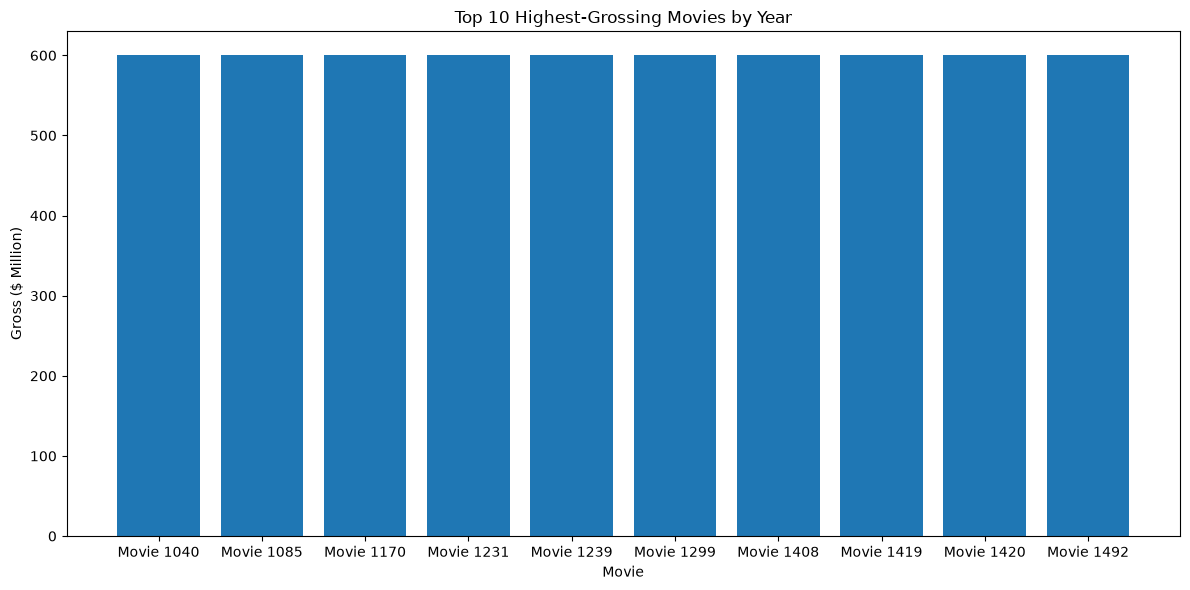

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    result2["title"],
    result2["gross_million"]
)

plt.xlabel("Movie")
plt.ylabel("Gross ($ Million)")
plt.title("Top 10 Highest-Grossing Movies by Year")
# 
# plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("../dashboards/top_10_highest_grossing.png")
plt.show()


In [14]:
query_3 = """
SELECT
    genre,
    rating
FROM movies
WHERE rating IS NOT NULL;
"""

In [15]:
result3=pd.read_sql(query_3,connection)

C:\Users\anish\AppData\Local\Temp\ipykernel_20648\3156414923.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result3=pd.read_sql(query_3,connection)


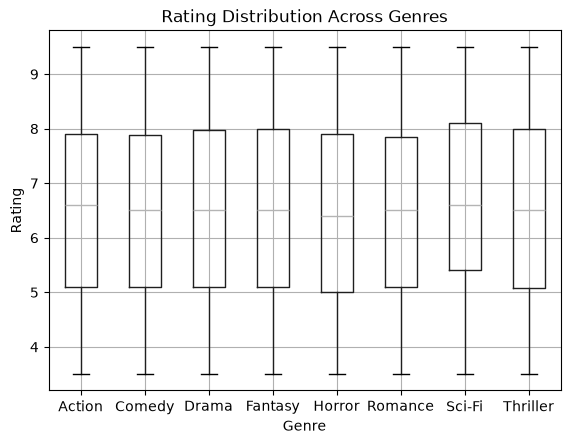

In [34]:

result3.boxplot(
    column="rating",
    by="genre"
)
plt.xlabel("Genre")
plt.ylabel("Rating")
plt.title("Rating Distribution Across Genres")

plt.suptitle("")
plt.savefig("../dashboards/Rating_Distribution_Across_Genres.png")
plt.show()

In [17]:
query_4 = """
SELECT
    director,
    AVG(rating) AS average_rating
FROM movies
WHERE rating IS NOT NULL  AND director <> 'Unknown'
GROUP BY director
ORDER BY average_rating DESC
LIMIT 5;
"""

In [18]:
result4 = pd.read_sql(query_4, connection)

C:\Users\anish\AppData\Local\Temp\ipykernel_20648\3314088242.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result4 = pd.read_sql(query_4, connection)


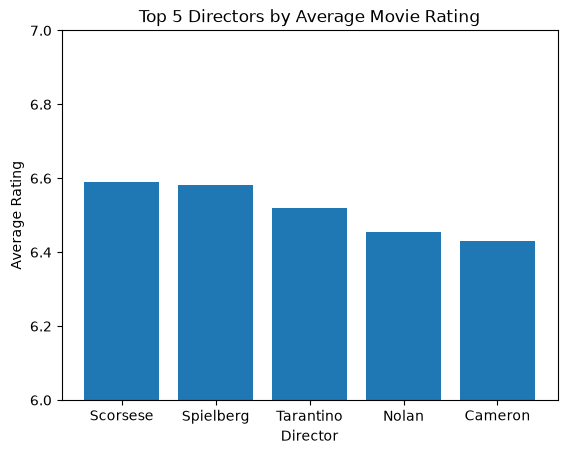

In [35]:
plt.bar(
    result4["director"],
    result4["average_rating"]
)

plt.xlabel("Director")
plt.ylabel("Average Rating")
plt.title("Top 5 Directors by Average Movie Rating")

plt.ylim(6, 7)
plt.savefig("../dashboards/Top_5_Directors.png")
plt.show()

Problem statement

Analyze budget vs gross correlation.

In [20]:
query_5 = """
SELECT
    budget_million,
    gross_million,
    genre
FROM movies

"""

In [21]:
result5 = pd.read_sql(query_5, connection)

C:\Users\anish\AppData\Local\Temp\ipykernel_20648\3689223710.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result5 = pd.read_sql(query_5, connection)


In [22]:
result5.head()

,budget_million,gross_million,genre
0,100.0,150.0,Thriller
1,150.0,150.0,Sci-Fi
2,30.0,600.0,Thriller
3,100.0,600.0,Thriller
4,10.0,600.0,Sci-Fi


In [23]:
correlation = result5["budget_million"].corr(
    result5["gross_million"]
)

print("Correlation:", correlation)

Correlation: 0.00521697747102233


There is almost no linear correlation between movie budget and gross revenue in your current dataset.
this value says that **Movies with higher budgets do not consistently have higher gross revenue in this dataset.**

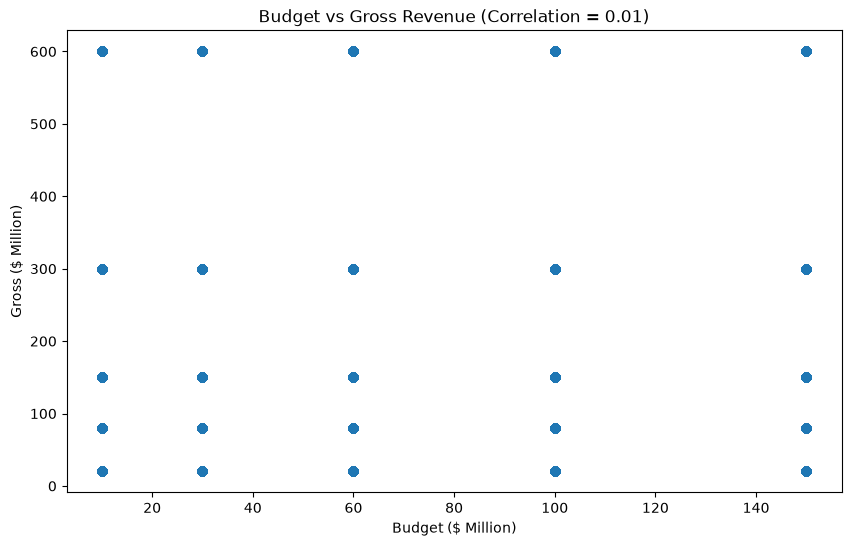

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    result5["budget_million"],
    result5["gross_million"]
)

plt.xlabel("Budget ($ Million)")
plt.ylabel("Gross ($ Million)")
plt.title(f"Budget vs Gross Revenue (Correlation = {correlation:.2f})")

plt.savefig("../dashboards/Budget_vs_Gross_Revenue.png")

plt.show()

import numpy as np

plt.figure(figsize=(10, 6))

for genre in result5["genre"].unique():

    genre_data = result5[result5["genre"] == genre]

    x = genre_data["budget_million"] + np.random.uniform(-2, 2, len(genre_data))# adding small jitter
    y = genre_data["gross_million"] + np.random.uniform(-5, 5, len(genre_data))

    plt.scatter(
        x,
        y,
        label=genre,
    )

plt.xlabel("Budget ($ Million)")
plt.ylabel("Gross ($ Million)")
plt.title(f"Budget vs Gross Revenue (Correlation = {correlation:.3f})")

plt.legend(title="Genre")

plt.tight_layout()
plt.show()
(advance code)

5. Identify most profitable genre.

In [25]:
query6="""
select 
avg(profit_million) as 'Average profit',
genre
from movies
group by genre
order by avg(profit_million) DESC"""

In [26]:
result6=pd.read_sql(query6,connection)

C:\Users\anish\AppData\Local\Temp\ipykernel_20648\3301024506.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result6=pd.read_sql(query6,connection)


In [27]:
result6.head(10)

,Average profit,genre
0,154.524496,Fantasy
1,154.483283,Drama
2,152.210526,Action
3,150.997110,Thriller
4,146.304654,Sci-Fi
5,145.826087,Comedy
6,143.656821,Romance
7,140.198777,Horror


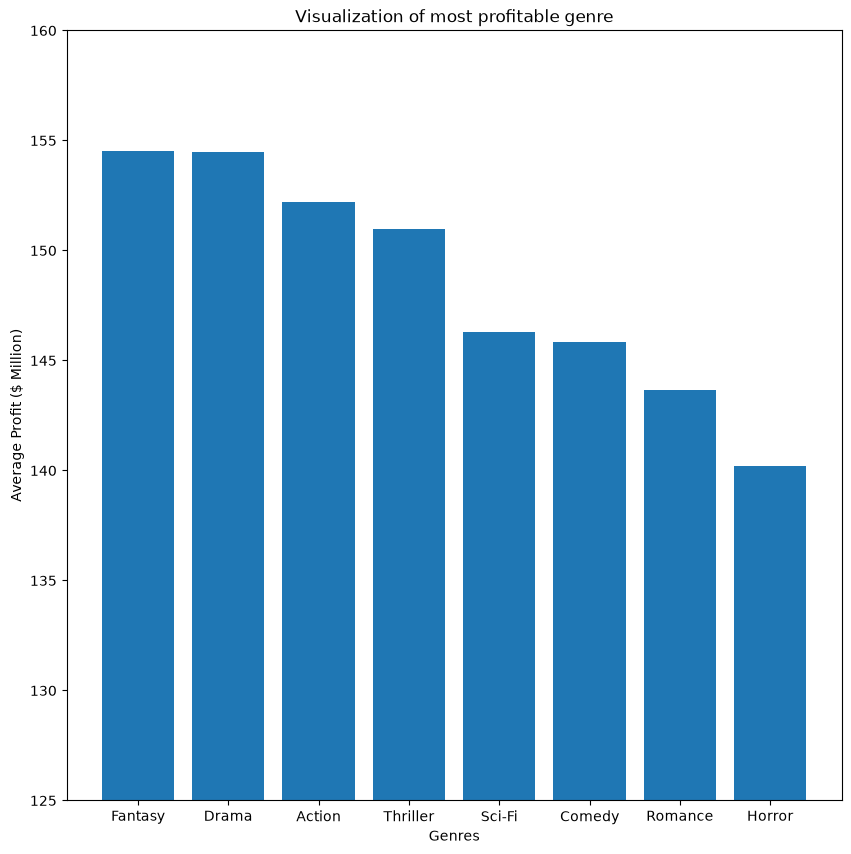

In [37]:
plt.figure(figsize=(10,10))
plt.bar(
    result6['genre'],
    result6['Average profit'],
    
)
plt.ylim(125,160)
plt.xlabel("Genres")
plt.ylabel("Average Profit ($ Million)")
plt.title("Visualization of most profitable genre")
plt.savefig("../dashboards/Visualization_of_most_profitable_genre.png")